## 1. Import Libraries and Setup

In [ ]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
# os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"
    # Reduces the number of warnings
os.makedirs("models", exist_ok=True)
os.makedirs("models/fine_tuned", exist_ok=True)
os.makedirs("models/classifiers", exist_ok=True)
    
import tensorflow as tf
from tensorflow import keras
from keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow_datasets as tfds

# Configure matplotlib for inline plotting
%matplotlib inline

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("="*60)
print("STL-10 Dataset CNN Classifier")
print("="*60)
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")
print("="*60)

gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
# To avoid stalling due to memory problems

STL-10 Dataset CNN Classifier
TensorFlow version: 2.19.1
Keras version: 3.14.0
GPU Available: True


## 2. Configuration parameters

In [2]:
IMG_SIZE = 64  # STL-10 native size (changed for faster training)
BATCH_SIZE = 128
EPOCHS = 200
NUM_CLASSES = 10  # airplane, bird, car, cat, deer, dog, horse, monkey, ship, truck
INITIAL_LR = 0.001

# Class names for visualization
CLASS_NAMES = [
    "airplane",
    "bird",
    "car",
    "cat",
    "deer",
    "dog",
    "horse",
    "monkey",
    "ship",
    "truck",
]

print(f"Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Number of Classes: {NUM_CLASSES}")
print(f"Initial Learning Rate: {INITIAL_LR}")
print(f"\nClasses: {', '.join(CLASS_NAMES)}")

Image Size: 64x64
Batch Size: 128
Epochs: 200
Number of Classes: 10
Initial Learning Rate: 0.001

Classes: airplane, bird, car, cat, deer, dog, horse, monkey, ship, truck


In [10]:
# ── Palette ──────────────────────────────────────────────────────────────────
_PALETTE = {
    "train": "#01696f",  # teal
    "val": "#da7101",  # orange
    "bg": "#f7f6f2",
    "surface": "#ffffff",
    "text": "#28251d",
    "text_muted": "#7a7974",
    "grid": "#dcd9d5",
    "divider": "#edeae5",
}


def _apply_style(ax, title="", xlabel="", ylabel=""):
    """Apply a clean, consistent look to a single Axes."""
    ax.set_facecolor(_PALETTE["surface"])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(_PALETTE["grid"])
    ax.spines["bottom"].set_color(_PALETTE["grid"])
    ax.tick_params(colors=_PALETTE["text_muted"], labelsize=9)
    ax.grid(axis="y", color=_PALETTE["grid"], linewidth=0.6, linestyle="--")
    ax.set_axisbelow(True)
    if title:
        ax.set_title(
            title, fontsize=11, fontweight="bold", color=_PALETTE["text"], pad=8
        )
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=9, color=_PALETTE["text_muted"])
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=9, color=_PALETTE["text_muted"])


# ── 1. Autoencoder training history ──────────────────────────────────────────
def plot_ae_history(
    history, metric="loss", title="Autoencoder Training", figsize=(9, 4), save_path=None
):
    """
    Plot training (and optional validation) reconstruction loss over epochs.

    Parameters
    ----------
    history : keras.callbacks.History or dict
        Keras History object returned by `model.fit()`, or a plain dict with
        the same key structure.
    metric : str
        Key name in history.history to plot (default: "loss").
    title : str
        Figure title.
    figsize : tuple
        Width × height in inches.
    save_path : str or None
        If given, saves the figure to this path (PNG at 150 dpi).
    """
    h = history.history if hasattr(history, "history") else history
    epochs = range(1, len(h[metric]) + 1)

    fig, ax = plt.subplots(figsize=figsize, facecolor=_PALETTE["bg"])
    fig.patch.set_facecolor(_PALETTE["bg"])

    ax.plot(epochs, h[metric], color=_PALETTE["train"], lw=2.0, label="Train loss")

    val_key = f"val_{metric}"
    if val_key in h:
        ax.plot(
            epochs,
            h[val_key],
            color=_PALETTE["val"],
            lw=2.0,
            linestyle="--",
            label="Val loss",
        )
        # Annotate best validation loss
        best_ep = np.argmin(h[val_key]) + 1
        best_val = min(h[val_key])
        ax.axvline(best_ep, color=_PALETTE["val"], lw=0.8, linestyle=":", alpha=0.7)
        ax.annotate(
            f"Best val: {best_val:.5f}\n(epoch {best_ep})",
            xy=(best_ep, best_val),
            xytext=(0, 20),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8,
            color=_PALETTE["val"],
            arrowprops=dict(arrowstyle="->", color=_PALETTE["val"], lw=0.8),
        )
    ax.legend(
        fontsize=9,
        framealpha=0.7,
        facecolor=_PALETTE["surface"],
        edgecolor=_PALETTE["grid"],
    )
    _apply_style(
        ax, title=title, xlabel="Epoch", ylabel=metric.replace("_", " ").title()
    )

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


# ── 2. Image reconstructions ─────────────────────────────────────────────────
def plot_reconstructions(
    originals,
    reconstructions,
    n=8,
    title="Original vs. Reconstructed",
    figsize=None,
    save_path=None,
):
    """
    Side-by-side grid of original and reconstructed images.

    Parameters
    ----------
    originals : np.ndarray, shape (N, H, W, C) or (N, H, W)
        Batch of original images (float32, values in [0, 1]).
    reconstructions : np.ndarray, same shape
        Corresponding reconstructed images from the decoder.
    n : int
        Number of image pairs to show (capped at len(originals)).
    title : str
        Figure super-title.
    figsize : tuple or None
        Override auto figure size.
    save_path : str or None
        Optional save path.
    """
    n = min(n, len(originals))
    if figsize is None:
        figsize = (n * 1.8 + 0.5, 4.0)

    fig, axes = plt.subplots(2, n, figsize=figsize, facecolor=_PALETTE["bg"])
    fig.patch.set_facecolor(_PALETTE["bg"])
    fig.suptitle(title, fontsize=12, fontweight="bold", color=_PALETTE["text"], y=1.01)

    row_labels = ["Original", "Reconstructed"]
    cmap = None if originals.ndim == 4 and originals.shape[-1] == 3 else "gray"

    for row, (imgs, label) in enumerate(zip([originals, reconstructions], row_labels)):
        for col in range(n):
            ax = axes[row, col]
            img = np.clip(imgs[col], 0.0, 1.0)
            if img.shape[-1] == 1:
                img = img.squeeze(-1)
            ax.imshow(img, cmap=cmap)
            ax.axis("off")
            if col == 0:
                ax.set_ylabel(
                    label, fontsize=9, color=_PALETTE["text_muted"], labelpad=4
                )

    # Thin divider between rows
    for col in range(n):
        for row in range(2):
            for spine in axes[row, col].spines.values():
                spine.set_visible(False)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def plot_clf_history(
    history, title="Classifier Training", figsize=(10, 4), save_path=None
):
    """
    Two-panel plot: loss (left) and accuracy (right) for a classifier.

    Parameters
    ----------
    history : keras.callbacks.History or dict
    title : str
    figsize : tuple
    save_path : str or None
    """
    h = history.history if hasattr(history, "history") else history
    epochs = range(1, len(h["loss"]) + 1)

    fig, (ax_loss, ax_acc) = plt.subplots(
        1, 2, figsize=figsize, facecolor=_PALETTE["bg"]
    )
    fig.patch.set_facecolor(_PALETTE["bg"])
    fig.suptitle(title, fontsize=12, fontweight="bold", color=_PALETTE["text"])

    # ── Loss ──
    ax_loss.plot(epochs, h["loss"], color=_PALETTE["train"], lw=2.0, label="Train")
    if "val_loss" in h:
        ax_loss.plot(
            epochs,
            h["val_loss"],
            color=_PALETTE["val"],
            lw=2.0,
            linestyle="--",
            label="Val",
        )
    ax_loss.legend(
        fontsize=9, facecolor=_PALETTE["surface"], edgecolor=_PALETTE["grid"]
    )
    _apply_style(ax_loss, title="Loss", xlabel="Epoch", ylabel="Loss")

    # ── Accuracy ──
    acc_key = "accuracy" if "accuracy" in h else "acc"
    val_acc_key = f"val_{acc_key}"
    ax_acc.plot(epochs, h[acc_key], color=_PALETTE["train"], lw=2.0, label="Train")
    if val_acc_key in h:
        ax_acc.plot(
            epochs,
            h[val_acc_key],
            color=_PALETTE["val"],
            lw=2.0,
            linestyle="--",
            label="Val",
        )
        best_ep = np.argmax(h[val_acc_key]) + 1
        best_acc = max(h[val_acc_key])
        ax_acc.axvline(best_ep, color=_PALETTE["val"], lw=0.8, linestyle=":", alpha=0.7)
        ax_acc.annotate(
            f"Best: {best_acc:.3f}\n(ep {best_ep})",
            xy=(best_ep, best_acc),
            xytext=(0, 20),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8,
            color=_PALETTE["val"],
            arrowprops=dict(arrowstyle="->", color=_PALETTE["val"], lw=0.8),
        )
    ax_acc.set_ylim(0, 1.05)
    ax_acc.legend(fontsize=9, facecolor=_PALETTE["surface"], edgecolor=_PALETTE["grid"])
    _apply_style(ax_acc, title="Accuracy", xlabel="Epoch", ylabel="Accuracy")

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

## 3. Load STL-10 dataset

In [3]:
print("  Downloading STL-10 dataset...\n")

ds_unlabeled_raw, ds_info = tfds.load(
    "stl10",
    split="unlabelled",
    as_supervised=False,
    with_info=True,
    data_dir="data",
    download=False,
)


def ae_preprocess(example):
    image = tf.cast(example["image"], tf.float32) / 255.0
    # Resize the image to the desired size (if needed)
    if IMG_SIZE != 96:
        image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    return image, image


ds_unlabeled_unbatched = (
    ds_unlabeled_raw.map(ae_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .ignore_errors()
    .cache()
    .shuffle(20_000, seed=42)
)

unlabelled_size = ds_info.splits["unlabelled"].num_examples

print(f"  Dataset loaded successfully!")
print(f"   Number of samples: {unlabelled_size}")

print(f"   Image shape: {ds_info.features['image'].shape}")
print(f"\n  Dataset Info:")
print(ds_info)


  Dataset loaded successfully!
   Number of samples: 100000
   Image shape: (96, 96, 3)

  Dataset Info:
tfds.core.DatasetInfo(
    name='stl10',
    full_name='stl10/1.0.0',
    description="""
    The STL-10 dataset is an image recognition dataset for developing unsupervised
    feature learning, deep learning, self-taught learning algorithms. It is inspired
    by the CIFAR-10 dataset but with some modifications. In particular, each class
    has fewer labeled training examples than in CIFAR-10, but a very large set of
    unlabeled examples is provided to learn image models prior to supervised
    training. The primary challenge is to make use of the unlabeled data (which
    comes from a similar but different distribution from the labeled data) to build
    a useful prior. All images were acquired from labeled examples on ImageNet.
    """,
    homepage='http://ai.stanford.edu/~acoates/stl10/',
    data_dir='data/stl10/1.0.0',
    file_format=tfrecord,
    download_size=2.46 GiB,

I0000 00:00:1778692658.064170 6752836 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1778692658.064314 6752836 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


**Important:** When loading the models, using ``.repeat()`` helps prevent errors caused by corrupted samples. You must then specify the ``steps_per_epoch`` argument during training as shown below.

````
steps_per_epoch = unlabelled_size // BATCH_SIZE
autoencoder.fit(
    ds_unlabeled,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_data=None
)


In [4]:
SUBSET_SIZE = 50000
train_frac = 0.8
val_frac = 0.1
test_frac = 0.1

train_size = int(SUBSET_SIZE * train_frac)  # 40000
val_size = int(SUBSET_SIZE * val_frac)  # 5000
test_size = SUBSET_SIZE - train_size - val_size  # 5000

train_steps = train_size // BATCH_SIZE
val_steps = val_size // BATCH_SIZE
test_steps = test_size // BATCH_SIZE

In [5]:
subset = ds_unlabeled_unbatched.take(SUBSET_SIZE)

ds_train_unbatched = subset.take(train_size)
ds_val_unbatched = subset.skip(train_size).take(val_size)
ds_test_unbatched = subset.skip(train_size + val_size).take(test_size)

print(f"  Training set size: {train_size}")
print(f"  Validation set size: {val_size}")
print(f"  Test set size: {test_size}")

  Training set size: 40000
  Validation set size: 5000
  Test set size: 5000


In [6]:
ds_train_unl = ds_train_unbatched.batch(BATCH_SIZE).repeat().prefetch(tf.data.AUTOTUNE)
ds_val_unl = ds_val_unbatched.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
ds_test_unl = ds_test_unbatched.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

## Training the autoencoders

We start by training an autoencder with moderate depth. The point of autoencoders is to learn a compressed representation of the data, therefore we need to create a bottleneck between the encoder and decoder. The size of the bottleneck is something we can control by tweking sizes of the layers in the encoder/decoder. Since we will be using images of size (64, 64, 3), this gives us a sample size of 12.288. 

To start we are going to aim for a latent space of around 8.000. To achieve it we are going to use the following architecture:

In [7]:
# Encoder
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Block 1
x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(inputs)
x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(inputs)
x = layers.MaxPooling2D((2, 2), padding="same")(x)  # 32x32x32

# Block 2
x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
x = layers.MaxPooling2D((2, 2), padding="same")(x)  # 16x16x64

x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
latent = layers.MaxPooling2D((2, 2), padding="same")(
    x
)  # 8x8x128 = 8192 dimensions in the latent space

encoder = models.Model(inputs, latent, name="encoder")
encoder.summary()

# Decoder
latent_inputs = layers.Input(shape=encoder.output_shape[1:], name="latent_input")
x = layers.Conv2DTranspose(128, (3, 3), strides=2, activation="relu", padding="same")(
    latent_inputs
)
x = layers.Conv2DTranspose(64, (3, 3), strides=2, activation="relu", padding="same")(x)
x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation="relu", padding="same")(x)
outputs = layers.Conv2D(3, (3, 3), activation="sigmoid", padding="same")(x)

decoder = models.Model(latent_inputs, outputs, name="decoder")
decoder.summary()

# Build the autoencoder by connecting encoder and decoder
latent = encoder.output
reconstructed = decoder(latent)

autoencoder = models.Model(encoder.input, reconstructed, name="autoencoder")

autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=INITIAL_LR), loss="mse"
)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True
    ),
    keras.callbacks.ModelCheckpoint(
        "models/autoencoder_v1.keras", monitor="val_loss", save_best_only=True
    ),
]

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,176 (508.50 KB)

 Trainable params: 130,176 (508.50 KB)

 Non-trainable params: 0 (0.00 B)

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ latent_input (InputLayer)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 64, 64, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 240,707 (940.26 KB)

 Trainable params: 240,707 (940.26 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = autoencoder.fit(
    ds_train_unl,
    epochs=EPOCHS,
    steps_per_epoch=train_steps,
    validation_data=ds_val_unl,
    validation_steps=val_steps,
    callbacks=callbacks,
)
encoder.save("models/encoder_v1.keras")

Epoch 1/200
312/312 ━━━━━━━━━━━━━━━━━━━━ 25s 73ms/step - loss: 0.0195 - val_loss: 0.0106
Epoch 2/200
312/312 ━━━━━━━━━━━━━━━━━━━━ 24s 75ms/step - loss: 0.0088 - val_loss: 0.0079
Epoch 3/200
312/312 ━━━━━━━━━━━━━━━━━━━━ 24s 78ms/step - loss: 0.0073 - val_loss: 0.0077
Epoch 4/200
312/312 ━━━━━━━━━━━━━━━━━━━━ 23s 74ms/step - loss: 0.0065 - val_loss: 0.0062
Epoch 5/200
312/312 ━━━━━━━━━━━━━━━━━━━━ 24s 78ms/step - loss: 0.0061 - val_loss: 0.0055
Epoch 6/200
312/312 ━━━━━━━━━━━━━━━━━━━━ 24s 77ms/step - loss: 0.0054 - val_loss: 0.0053
Epoch 7/200
312/312 ━━━━━━━━━━━━━━━━━━━━ 24s 77ms/step - loss: 0.0051 - val_loss: 0.0050
Epoch 8/200
312/312 ━━━━━━━━━━━━━━━━━━━━ 24s 76ms/step - loss: 0.0049 - val_loss: 0.0047
Epoch 9/200
312/312 ━━━━━━━━━━━━━━━━━━━━ 24s 77ms/step - loss: 0.0048 - val_loss: 0.0046
Epoch 10/200
312/312 ━━━━━━━━━━━━━━━━━━━━ 24s 78ms/step - loss: 0.0046 - val_loss: 0.0045
Epoch 11/200
312/312 ━━━━━━━━━━━━━━━━━━━━ 24s 77ms/step - loss: 0.0045 - val_loss: 0.0044
Epoch 12/200
312/31

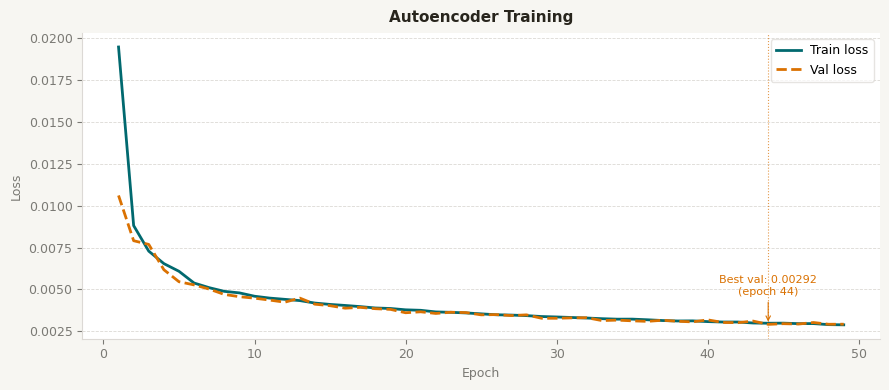

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step


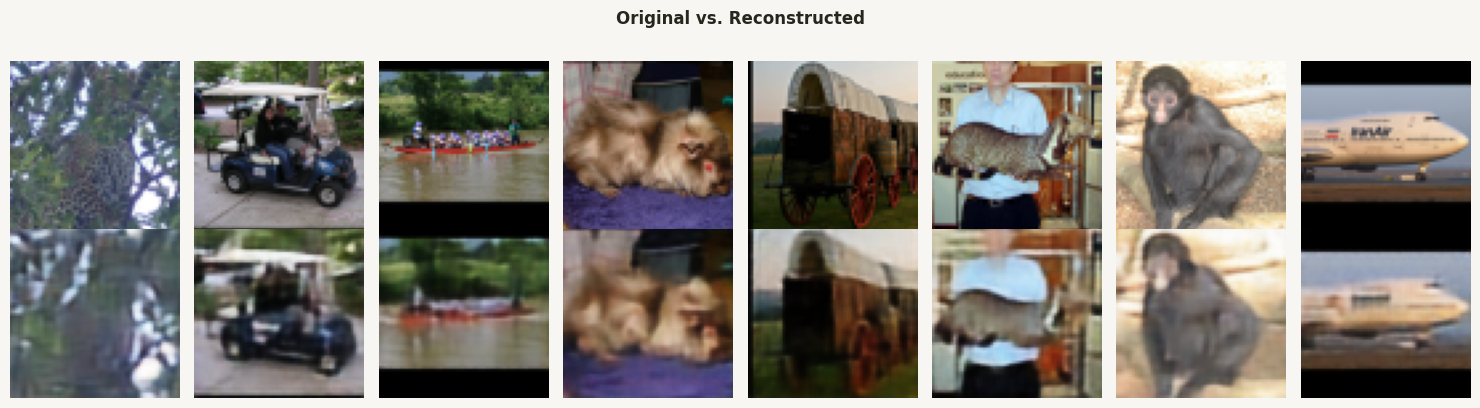

In [11]:
plot_ae_history(history)

batch = ds_test_unbatched.take(8).batch(8).prefetch(tf.data.AUTOTUNE)
images, targets = next(iter(batch))

recons = autoencoder.predict(images)
plot_reconstructions(images.numpy(), recons)

### Bottleneck Size Experiments

To see the effect of the bottleneck size on the performance of the AE, we can experiment with different sizes that start from the base AE. For these experiments we will try different sizes but they will be smaller than the base AE. Nevertheless, they have a similar architecture, following a convolutional bottleneck design. The bottleneck sizes we will try are:

1. **AE-1 latent_64**: Bottleneck size of ~4.000 (4x4x256)
2. **AE-2 latent_128**: Bottleneck size of ~2.000 (4x4x128)
3. **AE-3 latent_256**: Bottleneck size of ~1.000 (4x4x64)

In [12]:
def build_autoencoder_bottleneck(
    img_size: int = 64,
    latent_dims: int = 4096,
    base_filters: list[int] = [32, 64, 128, 256],
    n_conv: list[int] = [2, 2, 1],
) -> tuple[keras.Model, keras.Model, keras.Model]:
    inputs = layers.Input(shape=(img_size, img_size, 3))
    x = inputs

    # Encoder ------------------------------
    for i in range(len(base_filters) - 1):
        filters = base_filters[i]
        for j in range(n_conv[i]):
            x = layers.Conv2D(filters, (3, 3), activation="relu", padding="same")(x)
        x = layers.MaxPooling2D((2, 2), padding="same")(x)

    # Bottleneck
    conv_out_shape = tuple(x.shape[1:])  # e.g. (8, 8, 128)
    conv_out_dims = int(np.prod(conv_out_shape))

    # Last conv block instead of dense layer
    x = layers.Conv2D(256, (3, 3), activation="relu", padding="same")(x)
    latent = layers.Conv2D(
        latent_dims, (3, 3), strides=2, padding="same", name="latent_out"
    )(x)

    encoder = models.Model(inputs, latent, name=f"encoder_latent_{latent_dims}")

    # Decoder ------------------------------
    spatial_dim = img_size // (2 ** len(base_filters))

    latent_inputs = layers.Input(
        shape=(spatial_dim, spatial_dim, latent_dims), name="latent_input"
    )
    x = latent_inputs
    for i in reversed(range(len(base_filters))):
        filters = base_filters[i]
        x = layers.Conv2DTranspose(
            filters, (3, 3), strides=2, activation="relu", padding="same"
        )(x)

    outputs = layers.Conv2D(
        3, (3, 3), activation="sigmoid", padding="same", name="decoder_output"
    )(x)

    decoder = models.Model(latent_inputs, outputs, name=f"decoder_latent_{latent_dims}")

    # Autoencoder ------------------------------
    reconstructed = decoder(encoder(inputs))
    autoencoder = models.Model(
        inputs, reconstructed, name=f"autoencoder_latent_{latent_dims}"
    )

    return autoencoder, encoder, decoder

In [13]:
def train_autoencoder_latent(
    img_size: int,
    latent_dim: int,
    ds_train_unl: tf.data.Dataset,
    ds_val_unl: tf.data.Dataset,
    train_steps: int,
    val_steps: int,
    initial_lr: float,
    epochs: int,
    model_dir="models",
) -> tuple[keras.Model, keras.Model, keras.Model, keras.callbacks.History]:
    autoencoder, encoder, decoder = build_autoencoder_bottleneck(
        img_size=img_size, latent_dims=latent_dim
    )

    autoencoder.compile(
        optimizer=keras.optimizers.Adam(learning_rate=initial_lr), loss="mse"
    )

    encoder.summary()
    decoder.summary()

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=5, restore_best_weights=True
        ),
        keras.callbacks.ModelCheckpoint(
            f"{model_dir}/autoencoder_latent_{latent_dim}.keras",
            monitor="val_loss",
            save_best_only=True,
        ),
    ]

    history = autoencoder.fit(
        ds_train_unl,
        epochs=epochs,
        steps_per_epoch=train_steps,
        validation_data=ds_val_unl,
        validation_steps=val_steps,
        callbacks=callbacks,
    )

    encoder.save(f"{model_dir}/encoder_latent_{latent_dim}.keras")
    decoder.save(f"{model_dir}/decoder_latent_{latent_dim}.keras")

    return encoder, decoder, autoencoder, history

In [14]:
latent_dims_list = [64, 128, 256]
results = {}
for latent_dim in latent_dims_list:
    print(f"\nTraining autoencoder -> latent dims: {latent_dim}\n")
    encoder, decoder, autoencoder, history = train_autoencoder_latent(
        img_size=IMG_SIZE,
        latent_dim=latent_dim,
        ds_train_unl=ds_train_unl,
        ds_val_unl=ds_val_unl,
        train_steps=train_steps,
        val_steps=val_steps,
        initial_lr=INITIAL_LR,
        epochs=EPOCHS,
    )
    results[latent_dim] = {
        "encoder": encoder,
        "decoder": decoder,
        "autoencoder": autoencoder,
        "history": history,
    }


Training autoencoder -> latent dims: 64



Model: "encoder_latent_64"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_out (Conv2D)             │ (None, 4, 4, 64)       │       147,520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 582,112 (2.22 MB)

 Trainable params: 582,112 (2.22 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ latent_input (InputLayer)       │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_11             │ (None, 8, 8, 256)      │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_12             │ (None, 16, 16, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_13             │ (None, 32, 32, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_14             │ (None, 64, 64, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Conv2D)         │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 978,243 (3.73 MB)

 Trainable params: 978,243 (3.73 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
312/312 ━━━━━━━━━━━━━━━━━━━━ 35s 103ms/step - loss: 0.0252 - val_loss: 0.0140
Epoch 2/200
312/312 ━━━━━━━━━━━━━━━━━━━━ 33s 105ms/step - loss: 0.0131 - val_loss: 0.0100
Epoch 3/200
312/312 ━━━━━━━━━━━━━━━━━━━━ 33s 106ms/step - loss: 0.0091 - val_loss: 0.0083
Epoch 4/200
312/312 ━━━━━━━━━━━━━━━━━━━━ 32s 104ms/step - loss: 0.0081 - val_loss: 0.0078
Epoch 5/200
312/312 ━━━━━━━━━━━━━━━━━━━━ 34s 108ms/step - loss: 0.0075 - val_loss: 0.0075
Epoch 6/200
312/312 ━━━━━━━━━━━━━━━━━━━━ 33s 106ms/step - loss: 0.0068 - val_loss: 0.0064
Epoch 7/200
312/312 ━━━━━━━━━━━━━━━━━━━━ 33s 106ms/step - loss: 0.0062 - val_loss: 0.0058
Epoch 8/200
312/312 ━━━━━━━━━━━━━━━━━━━━ 32s 104ms/step - loss: 0.0058 - val_loss: 0.0058
Epoch 9/200
312/312 ━━━━━━━━━━━━━━━━━━━━ 33s 106ms/step - loss: 0.0054 - val_loss: 0.0053
Epoch 10/200
312/312 ━━━━━━━━━━━━━━━━━━━━ 33s 104ms/step - loss: 0.0052 - val_loss: 0.0049
Epoch 11/200
312/312 ━━━━━━━━━━━━━━━━━━━━ 33s 105ms/step - loss: 0.0050 - val_loss: 0.0048
Epoch 12

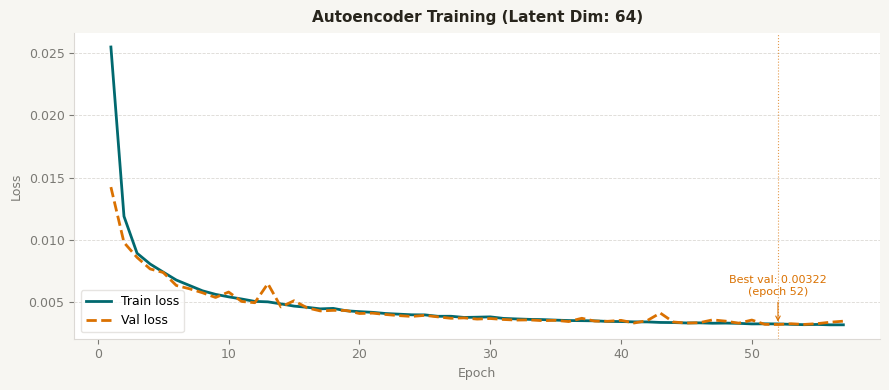


Reconstruction results for latent dim = 64

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step


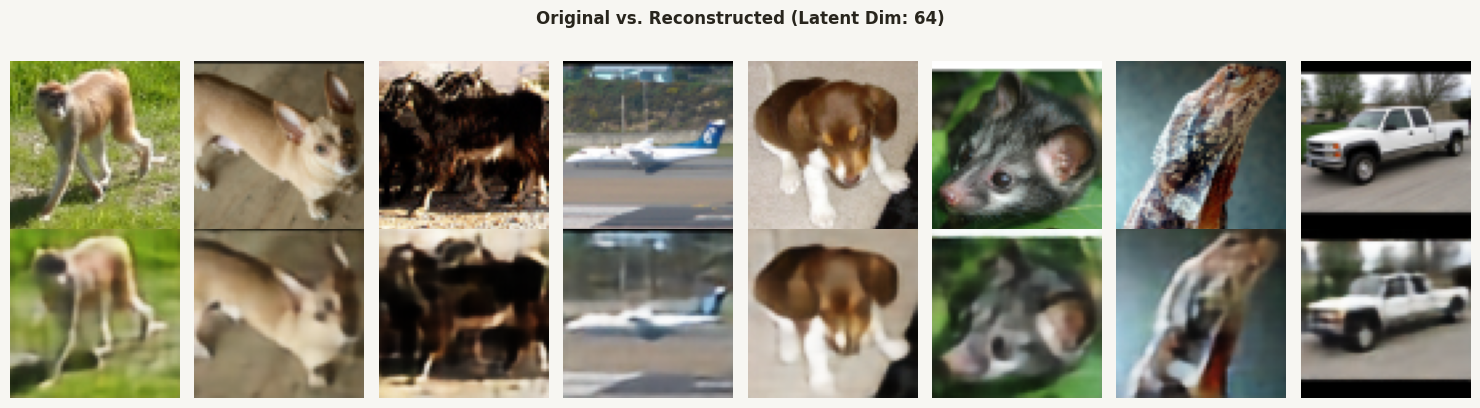

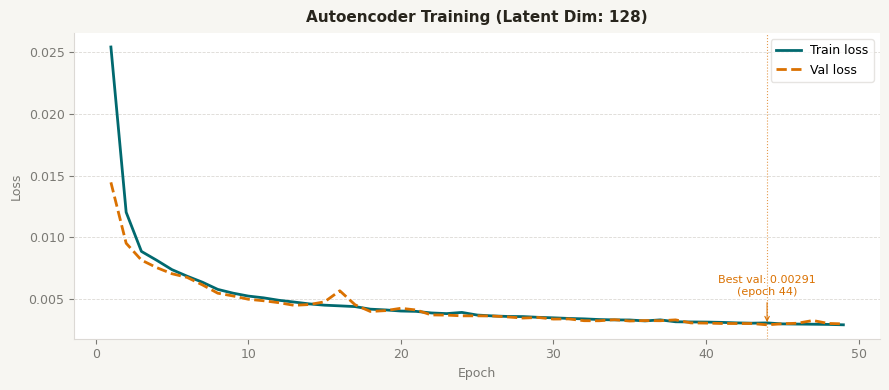


Reconstruction results for latent dim = 128

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step


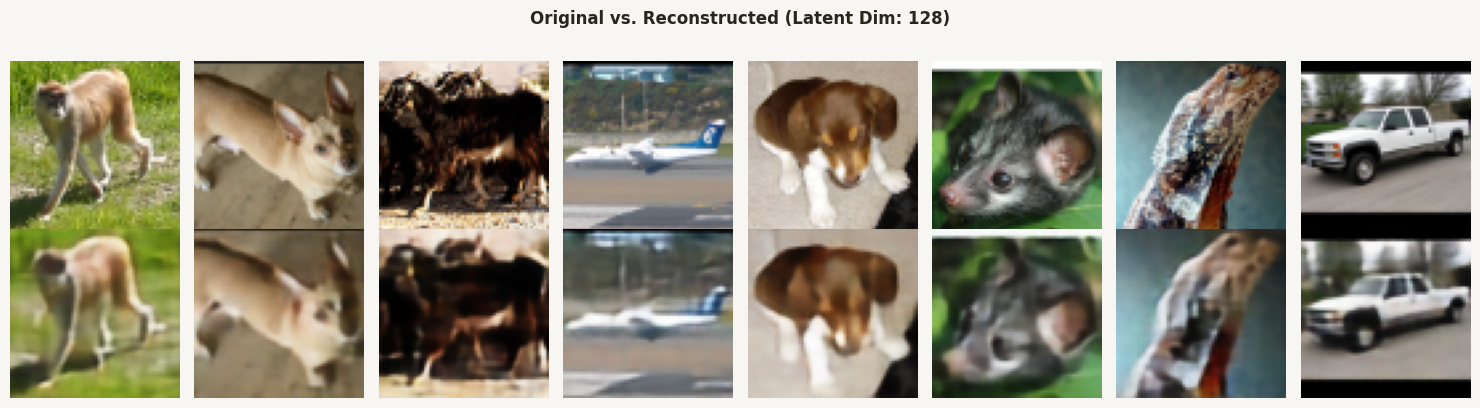

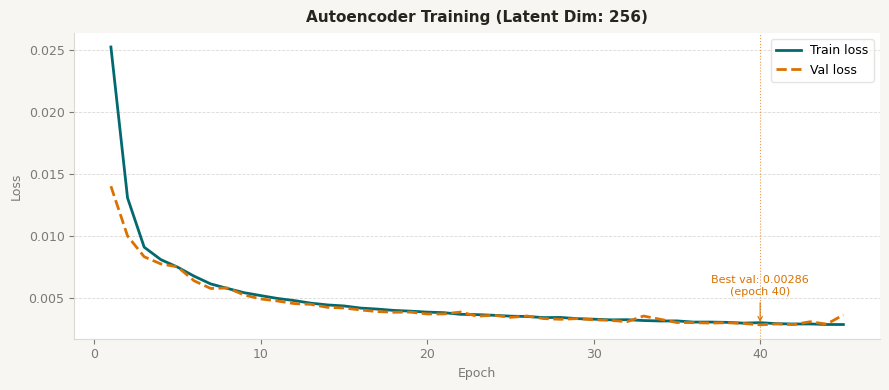


Reconstruction results for latent dim = 256

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


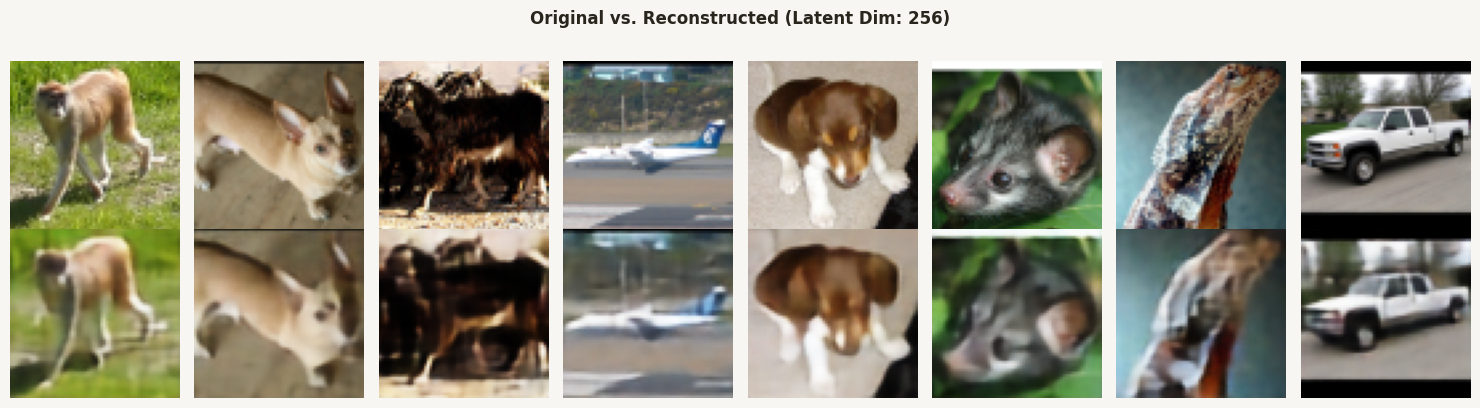

In [15]:
# Test the same images across all models for a fair comparison
batch = ds_test_unbatched.take(8).batch(8).prefetch(tf.data.AUTOTUNE)
images, targets = next(iter(batch))

for latent_dim, res in results.items():
    plot_ae_history(
        res["history"],
        title=f"Autoencoder Training (Latent Dim: {latent_dim})",
    )
    print(f"\nReconstruction results for latent dim = {latent_dim}\n")

    recons = res["autoencoder"].predict(images)
    plot_reconstructions(
        images.numpy(),
        recons,
        title=f"Original vs. Reconstructed (Latent Dim: {latent_dim})",
    )

In [17]:
from keras import layers, models


def preprocess_labeled(example):
    img = tf.cast(example["image"], tf.float32) / 255.0
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    label = tf.cast(example["label"], tf.int32)
    return img, label


ds_train, ds_test = tfds.load("stl10", as_supervised=True, split=["train", "test"], download=False)  # type: ignore


def normalize_pixel_values_and_ohe(image, label):
    # Normalize the image to [0, 1]
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    label = tf.one_hot(label, 10)
    return image, label


# Apply the preprocessing to the training and test datasets
ds_train = ds_train.map(normalize_pixel_values_and_ohe)
ds_test = ds_test.map(normalize_pixel_values_and_ohe)

# Create a validation set from the training set
validation_size = 1000

ds_val = ds_train.take(validation_size).batch(64).prefetch(tf.data.AUTOTUNE)
ds_train = (
    ds_train.skip(validation_size).batch(64).shuffle(1000).prefetch(tf.data.AUTOTUNE)
)

ds_test = ds_test.batch(64).prefetch(tf.data.AUTOTUNE)

data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1),
        layers.RandomTranslation(0.1, 0.1),
    ]
)


def augment_labeled(img, label):
    img = data_augmentation(img)
    return img, label


aug_train_ds = ds_train.map(
    augment_labeled, num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

aug_val_ds = ds_val.map(augment_labeled, num_parallel_calls=tf.data.AUTOTUNE).prefetch(
    tf.data.AUTOTUNE
)

In [18]:
def train_classifier(
    encoder: keras.Model,
    ds_train: tf.data.Dataset,
    ds_val: tf.data.Dataset,
    ds_test: tf.data.Dataset,
    initial_lr: float,
    epochs: int,
    model_dir="models/classifiers",
    fine_tune: bool = False,
) -> tuple[keras.Model, keras.callbacks.History, dict]:
    # Freeze the encoder weights
    encoder.trainable = False

    if fine_tune:
        print("\nFine-tuning the encoder layers...\n")
        # Unfreeze the last convolutional block (e.g., last 1 conv layers)
        for layer in encoder.layers[-1:]:
            layer.trainable = True

    # Build the classifier on top of the frozen encoder
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = encoder(inputs)
    x = layers.Flatten()(x)
    x = layers.Dense(
        256, activation="relu", kernel_regularizer=keras.regularizers.l2(1e-4)
    )(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    classifier = models.Model(inputs, outputs, name="classifier")

    classifier.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    classifier.summary()

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=7, restore_best_weights=True
        ),
        keras.callbacks.ModelCheckpoint(
            f"{model_dir}/classifier_{encoder.name}.keras",
            monitor="val_loss",
            save_best_only=True,
        ),
    ]

    history = classifier.fit(
        ds_train,
        epochs=epochs,
        validation_data=ds_val,
        callbacks=callbacks,
    )

    test_loss, test_acc = classifier.evaluate(ds_test)
    print(f"\nTest accuracy: {test_acc:.4f}")

    return classifier, history, {"test_loss": test_loss, "test_accuracy": test_acc}

In [19]:
from typing import cast

classification_results = {}

for latent_dim in latent_dims_list:
    encoder = keras.models.load_model(f"models/encoder_latent_{latent_dim}.keras")

    print(f"\nTraining classifier with encoder latent dim = {latent_dim}\n")
    classifier, history, test_metrics = train_classifier(
        encoder=encoder,
        ds_train=aug_train_ds,
        ds_val=ds_val,
        ds_test=ds_test,
        initial_lr=INITIAL_LR,
        epochs=EPOCHS,
    )
    classification_results[latent_dim] = {
        "classifier": classifier,
        "history": history,
        "test_metrics": test_metrics,
    }


Training classifier with encoder latent dim = 64



Model: "classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_latent_64 (Functional)  │ (None, 4, 4, 64)       │       582,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 847,082 (3.23 MB)

 Trainable params: 264,970 (1.01 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_latent_256 (Functional) │ (None, 4, 4, 256)      │     1,024,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,076,074 (7.92 MB)

 Trainable params: 1,051,402 (4.01 MB)

 Non-trainable params: 1,024,672 (3.91 MB)

Epoch 1/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.2465 - loss: 2.1801 - val_accuracy: 0.3520 - val_loss: 1.8071
Epoch 2/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3293 - loss: 1.8782 - val_accuracy: 0.4060 - val_loss: 1.6718
Epoch 3/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.3605 - loss: 1.7934 - val_accuracy: 0.4540 - val_loss: 1.5835
Epoch 4/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.3842 - loss: 1.7279 - val_accuracy: 0.4590 - val_loss: 1.5444
Epoch 5/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.4180 - loss: 1.6996 - val_accuracy: 0.4780 - val_loss: 1.5200
Epoch 6/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4067 - loss: 1.6643 - val_accuracy: 0.4790 - val_loss: 1.5006
Epoch 7/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.4315 - loss: 1.6338 - val_accuracy: 0.4980 - val_loss: 1.4595
Epoch 8/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.4330 - loss: 1.6332 - val_accuracy: 0.

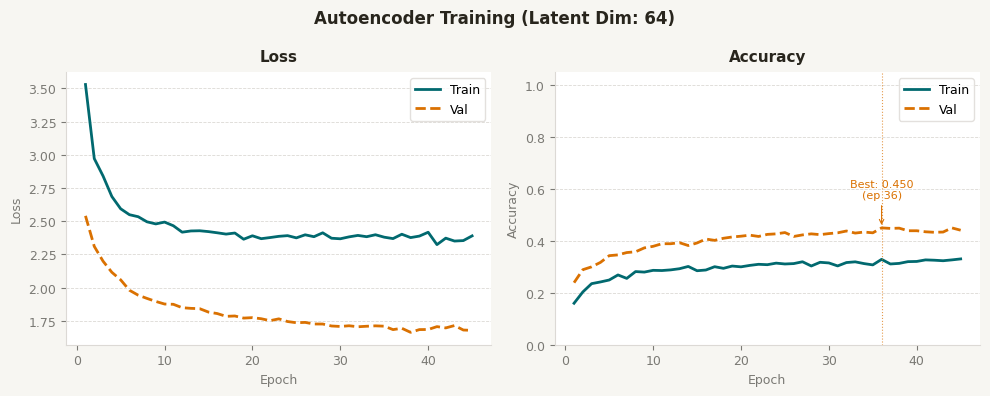

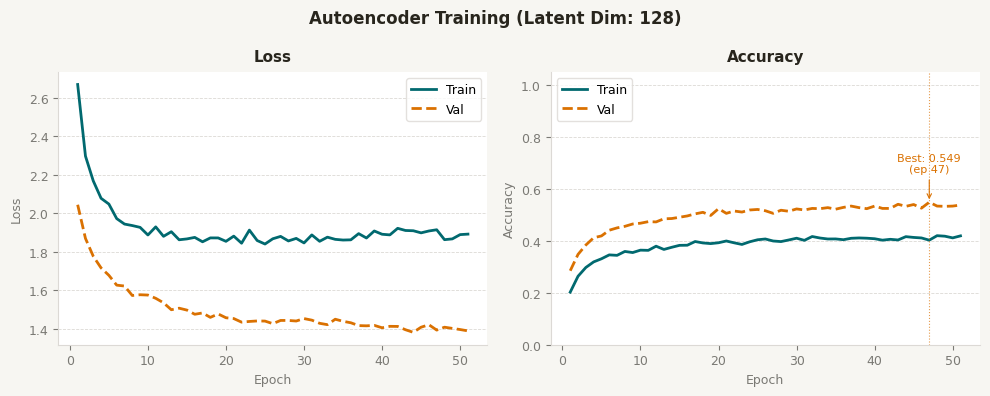

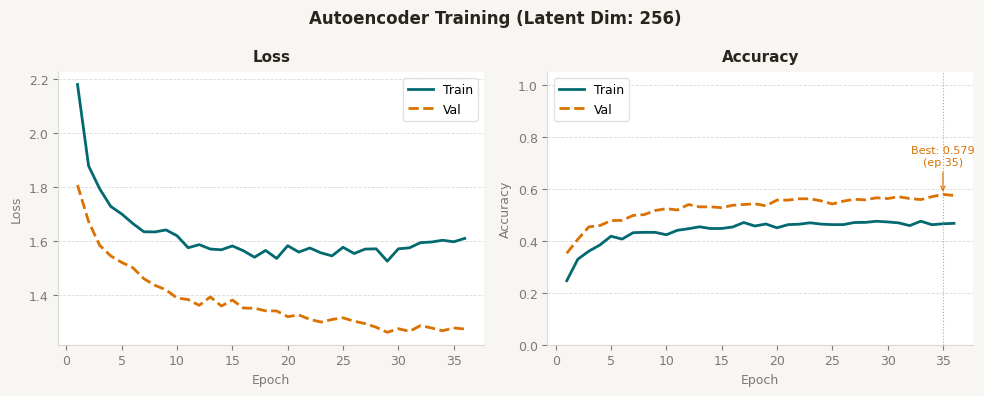

In [22]:
for latent_dim, res in classification_results.items():
    history = res["history"]
    plot_clf_history(
        history,
        title=f"Autoencoder Training (Latent Dim: {latent_dim})",
    )

FINE TUNNING 


Fine-tuning the encoder layers...



Model: "classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_latent_256 (Functional) │ (None, 4, 4, 256)      │     1,024,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,076,074 (7.92 MB)

 Trainable params: 1,641,482 (6.26 MB)

 Non-trainable params: 434,592 (1.66 MB)

Epoch 1/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.2442 - loss: 2.1995 - val_accuracy: 0.3440 - val_loss: 1.7947
Epoch 2/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.3225 - loss: 1.9192 - val_accuracy: 0.4060 - val_loss: 1.6447
Epoch 3/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.3598 - loss: 1.7981 - val_accuracy: 0.4470 - val_loss: 1.5541
Epoch 4/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.3977 - loss: 1.7047 - val_accuracy: 0.4690 - val_loss: 1.4874
Epoch 5/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.4105 - loss: 1.6640 - val_accuracy: 0.4770 - val_loss: 1.4755
Epoch 6/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.4157 - loss: 1.6453 - val_accuracy: 0.4760 - val_loss: 1.4766
Epoch 7/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.4330 - loss: 1.6132 - val_accuracy: 0.4920 - val_loss: 1.4168
Epoch 8/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.4392 - loss: 1.6018 - val_accuracy: 0.

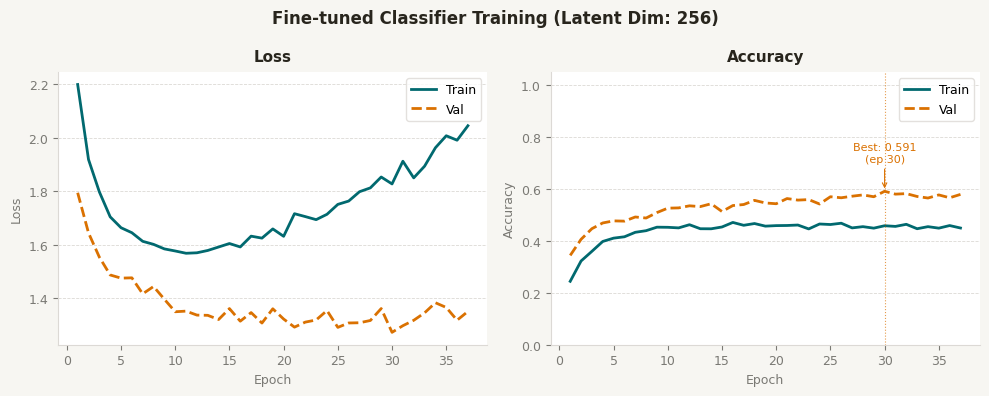

In [21]:
# Fine tunning on the model with best results (train classifier from scratch with the encoder weights unfrozen)

model = keras.models.load_model("models/encoder_latent_256.keras")

classifier, history, test_metrics = train_classifier(
    encoder=model,
    ds_train=aug_train_ds,
    ds_val=ds_val,
    ds_test=ds_test,
    initial_lr=1e-6,
    epochs=EPOCHS,
    model_dir="models/fine_tuned",
    fine_tune=True,
)

plot_clf_history(
    history,
    title=f"Fine-tuned Classifier Training (Latent Dim: 256)",
)